<a href="https://colab.research.google.com/github/the-sayandeep/sample-colab/blob/main/notebooks/colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Copyright (c) Meta Platforms, Inc. and affiliates. All rights reserved. This source code is licensed under the license found in the LICENSE file in the root directory of this source tree.

# Video Seal Inference

[[`arXiv`](https://arxiv.org/abs/2412.09492)]
[[`Colab`](https://colab.research.google.com/github/facebookresearch/videoseal/blob/main/notebooks/colab.ipynb)]
[[`Demo`](https://aidemos.meta.com/videoseal)]

## Installation

Clone repository and install dependencies

In [1]:
!git clone https://github.com/facebookresearch/videoseal.git
%cd videoseal

Cloning into 'videoseal'...
remote: Enumerating objects: 666, done.
remote: Counting objects: 100% (307/307), done.
remote: Compressing objects: 100% (155/155), done.
remote: Total 666 (delta 176), reused 152 (delta 152), pack-reused 359 (from 2)
Receiving objects: 100% (666/666), 27.82 MiB | 19.09 MiB/s, done.
Resolving deltas: 100% (300/300), done.
/content/videoseal


Install dependencies

In [2]:
!pip install -r requirements.txt

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 31.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.8/53.8 kB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 226.4/226.4 kB 16.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 36.4/36.4 MB 47.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.4/99.4 kB 7.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.8/5.8 MB 114.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 469.0/469.0 kB 31.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 74.5 MB/s eta 0:00:00
  Attempting uninstall: timm
    Found existing installation: timm 1.0.26
    Uninstalling timm-1.0.26:
      Successfully uninstalled timm-1.0.26


## Imports and loading

In [3]:
%cd /content/videoseal

/content/videoseal


In [10]:
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
import logging
logging.getLogger("matplotlib.image").setLevel(logging.ERROR)
from IPython.display import HTML, display

import pandas as pd
from tqdm import tqdm
import numpy as np
import ffmpeg
import os
import cv2
import subprocess

import torch

from PIL import Image
import matplotlib.pyplot as plt
import torchvision

from videoseal.utils.display import save_img
from videoseal.utils import Timer
from videoseal.evals.full import setup_model_from_checkpoint
from videoseal.evals.metrics import bit_accuracy, psnr, ssim
from videoseal.augmentation import Identity, JPEG
from videoseal.modules.jnd import JND

to_tensor = torchvision.transforms.ToTensor()
to_pil = torchvision.transforms.ToPILImage()

from videoseal.models import Videoseal
from videoseal.utils.cfg import setup_model_from_model_card


def get_video_info(input_path):
    # Open the video file
    video = cv2.VideoCapture(input_path)

    # Get video properties
    width = int(video.get(cv2.CAP_PROP_FRAME_WIDTH))
    height = int(video.get(cv2.CAP_PROP_FRAME_HEIGHT))
    fps = video.get(cv2.CAP_PROP_FPS)
    codec = int(video.get(cv2.CAP_PROP_FOURCC))
    num_frames = int(video.get(cv2.CAP_PROP_FRAME_COUNT))

    # Decode codec to human-readable form
    codec_str = "".join([chr((codec >> 8 * i) & 0xFF) for i in range(4)])

    video.release()  # Close the video file

    return {
        "width": width,
        "height": height,
        "fps": fps,
        "codec": codec_str,
        "num_frames": num_frames
    }

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

/content/videoseal/videoseal/evals/full.py:30: SyntaxWarning: invalid escape sequence '\ '
  --dataset sa-v --is_video true --num_samples 1 \


## Load the model

The videoseal library provides pretrained models for embedding and extracting watermarks.

In [11]:
# Load the VideoSeal model
model = setup_model_from_model_card("pixelseal")

# Set the model to evaluation mode and move it to the selected device
model = model.eval()
model = model.to(device)
model.compile()

# Setup the step size. Bigger step size makes embedding faster but loses a bit of robustness.
model.step_size = 8

File /content/videoseal/ckpts/pixelseal_checkpoint.pth exists, skipping download
Model loaded successfully from /content/videoseal/ckpts/pixelseal_checkpoint.pth with message: <All keys matched successfully>


## Embedding

The embedding process is the process of hiding the watermark in the video.

In [6]:
def embed_video_clip(
    model: Videoseal,
    clip: np.ndarray,
    msgs: torch.Tensor
) -> np.ndarray:
    clip_tensor = torch.tensor(clip, dtype=torch.float32).permute(0, 3, 1, 2) / 255.0
    outputs = model.embed(clip_tensor, msgs=msgs, is_video=True, lowres_attenuation=True)
    processed_clip = outputs["imgs_w"]
    processed_clip = (processed_clip * 255.0).byte().permute(0, 2, 3, 1).numpy()
    return processed_clip

def embed_video(
    model: Videoseal,
    input_path: str,
    output_path: str,
    chunk_size: int,
    crf: int = 23
) -> None:
    # Read video dimensions
    video_info = get_video_info(input_path)
    width = int(video_info['width'])
    height = int(video_info['height'])
    fps = float(video_info['fps'])
    codec = video_info['codec']
    num_frames = int(video_info['num_frames'])

    # Open the input video
    process1 = (
        ffmpeg
        .input(input_path)
        .output('pipe:', format='rawvideo', pix_fmt='rgb24', s='{}x{}'.format(width, height), r=fps)
        .run_async(pipe_stdout=True, pipe_stderr=subprocess.PIPE)
    )
    # Open the output video
    process2 = (
        ffmpeg
        .input('pipe:', format='rawvideo', pix_fmt='rgb24', s='{}x{}'.format(width, height), r=fps)
        .output(output_path, vcodec='libx264', pix_fmt='yuv420p', r=fps, crf=crf)
        .overwrite_output()
        .run_async(pipe_stdin=True, pipe_stderr=subprocess.PIPE)
    )

    # Create a random message
    msgs = model.get_random_msg()
    with open(output_path.replace(".mp4", ".txt"), "w") as f:
        f.write("".join([str(msg.item()) for msg in msgs[0]]))

    # Process the video
    frame_size = width * height * 3
    chunk = np.zeros((chunk_size, height, width, 3), dtype=np.uint8)
    frame_count = 0
    pbar = tqdm(total=num_frames, desc="Watermark embedding")
    while True:
        in_bytes = process1.stdout.read(frame_size)
        if not in_bytes:
            break
        frame = np.frombuffer(in_bytes, np.uint8).reshape([height, width, 3])
        chunk[frame_count % chunk_size] = frame
        frame_count += 1
        pbar.update(1)
        if frame_count % chunk_size == 0:
            processed_frame = embed_video_clip(model, chunk, msgs)
            process2.stdin.write(processed_frame.tobytes())
    process1.stdout.close()
    process2.stdin.close()
    process1.wait()
    process2.wait()

    return msgs

You are free to upload any video and change the `video_path`.

You can look at the watermark video output in the folder `outputs`.

In [14]:
# Path to the input video
image_path = "./assets/imgs/1.jpg"
imgs = Image.open(image_path, "r").convert("RGB")  # keep only rgb channels

imgs = to_tensor(imgs).unsqueeze(0).float()
timer = Timer()

# Watermark embedding
timer.start()

outputs = model.embed(imgs, is_video=False, lowres_attenuation=True)

timer.stop()


# Create the output directory and path
output_dir = "./outputs"
os.makedirs(output_dir, exist_ok=True)
output_path = os.path.join(output_dir, os.path.basename(image_path))

imgs_w = outputs["imgs_w"]  # b c h w
msgs = outputs["msgs"]  # b k
diff = imgs_w - imgs
diff = 25 * diff.abs()

# save
timer.start()
base_save_name = os.path.join(output_dir, os.path.basename(file).replace(".png", ""))
save_img(imgs[0], f"{base_save_name}_ori.png")
save_img(imgs_w[0], f"{base_save_name}_wm.png")
save_img(diff[0], f"{base_save_name}_diff.png")

# Metrics
imgs_aug = imgs_w
outputs = model.detect(imgs_aug, is_video=False)
metrics = {
    "file": file,
    "bit_accuracy": bit_accuracy(
        outputs["preds"][:, 1:],
        msgs
    ).nanmean().item(),
    "psnr": psnr(imgs_w, imgs).item(),
    "ssim": ssim(imgs_w, imgs).item()
}

print(f"\nSaved watermarked video to {output_path}")


Saved watermarked video to ./outputs/1.jpg


In [17]:
def plot_images(original, watermarked, diff):
    # plot original image, watermarked image, and difference
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    axes[0].imshow(original.permute(1, 2, 0).cpu().numpy())
    axes[0].set_title("Original Image")
    axes[0].axis("off")

    axes[1].imshow(watermarked.permute(1, 2, 0).cpu().numpy())
    axes[1].set_title("Watermarked Image")
    axes[1].axis("off")

    axes[2].imshow(diff.permute(1, 2, 0).cpu().numpy())
    axes[2].set_title("Difference Image")
    axes[2].axis("off")

    plt.show()

{'file': './assets/imgs/1.jpg', 'bit_accuracy': 1.0, 'psnr': 49.418209075927734, 'ssim': 0.9973915219306946, 'bit_accuracy_qf80': 1.0}


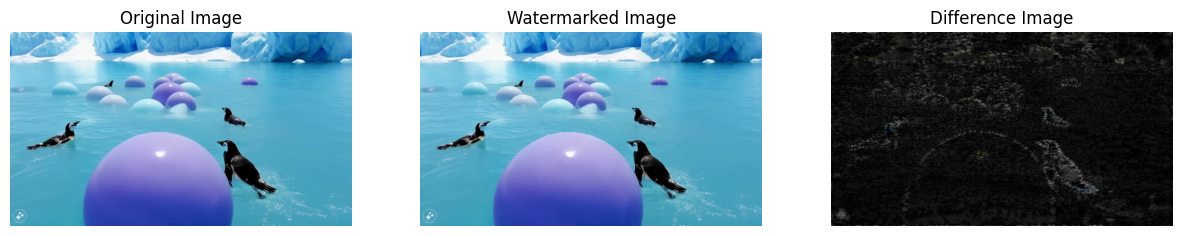

{'file': './assets/imgs/1.jpg', 'bit_accuracy': 1.0, 'psnr': 49.418209075927734, 'ssim': 0.9973915219306946, 'bit_accuracy_qf80': 1.0, 'bit_accuracy_qf40': 0.98046875}


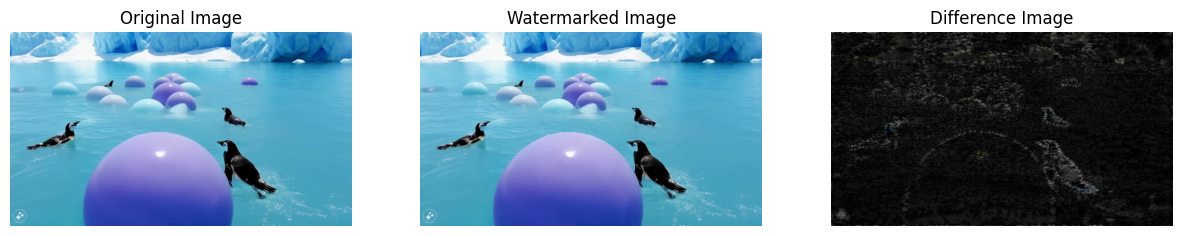

In [20]:
# Path to the input video
image_path = "./assets/imgs/1.jpg"
imgs = Image.open(image_path, "r").convert("RGB")  # keep only rgb channels

imgs = to_tensor(imgs).unsqueeze(0).float()
timer = Timer()

# Watermark embedding
timer.start()

outputs = model.embed(imgs, is_video=False, lowres_attenuation=True)

timer.stop()


# Create the output directory and path
output_dir = "./outputs"
os.makedirs(output_dir, exist_ok=True)
output_path = os.path.join(output_dir, os.path.basename(image_path))

imgs_w = outputs["imgs_w"]  # b c h w
msgs = outputs["msgs"]  # b k
diff = imgs_w - imgs
diff = 25 * diff.abs()

# save
timer.start()
base_save_name = os.path.join(output_dir, os.path.basename(image_path).replace(".png", ""))
save_img(imgs[0], f"{base_save_name}_ori.png")
save_img(imgs_w[0], f"{base_save_name}_wm.png")
save_img(diff[0], f"{base_save_name}_diff.png")

# Metrics
imgs_aug = imgs_w
outputs = model.detect(imgs_aug, is_video=False)
metrics = {
    "file": image_path,
    "bit_accuracy": bit_accuracy(
        outputs["preds"][:, 1:],
        msgs
    ).nanmean().item(),
    "psnr": psnr(imgs_w, imgs).item(),
    "ssim": ssim(imgs_w, imgs).item()
}

for qf in [80, 40]:
  imgs_aug, _ = JPEG()(imgs_w, None,qf)

  # detect
  timer.start()
  outputs = model.detect(imgs_aug, is_video=True)
  preds = outputs["preds"]
  bit_preds = preds[:, 1:]  # b k ...
  bit_accuracy_ = bit_accuracy(
      bit_preds,
      msgs
  ).nanmean().item()

  metrics[f"bit_accuracy_qf{qf}"] = bit_accuracy_

  print(metrics)
  plot_images(imgs[0], imgs_w[0], diff[0])

del outputs, imgs, imgs_w, diff

## Extraction

Load the video output from the embedding process and extract the watermark.

In [ ]:
def detect_video_clip(
    model: Videoseal,
    clip: np.ndarray
) -> torch.Tensor:
    clip_tensor = torch.tensor(clip, dtype=torch.float32).permute(0, 3, 1, 2) / 255.0
    outputs = model.detect(clip_tensor, is_video=True)
    output_bits = outputs["preds"][:, 1:]  # exclude the first which may be used for detection
    return output_bits

def detect_video(
    model: Videoseal,
    input_path: str,
    num_frames_for_extraction: int,
    chunk_size: int
) -> None:
    # Read video dimensions
    video_info = get_video_info(input_path)
    width = int(video_info['width'])
    height = int(video_info['height'])
    num_frames = int(video_info['num_frames'])

    # Open the input video
    process1 = (
        ffmpeg
        .input(input_path)
        .output('pipe:', format='rawvideo', pix_fmt='rgb24')
        .run_async(pipe_stdout=True, pipe_stderr=subprocess.PIPE)
    )

    # Process the video
    frame_size = width * height * 3
    chunk = np.zeros((chunk_size, height, width, 3), dtype=np.uint8)
    frame_count = 0
    soft_msgs = []
    pbar = tqdm(total=num_frames, desc="Watermark extraction")
    while True:
        if frame_count >= num_frames_for_extraction:
            break
        in_bytes = process1.stdout.read(frame_size)
        if not in_bytes:
            break
        frame = np.frombuffer(in_bytes, np.uint8).reshape([height, width, 3])
        chunk[frame_count % chunk_size] = frame
        frame_count += 1
        pbar.update(1)
        if frame_count % chunk_size == 0:
            soft_msgs.append(detect_video_clip(model, chunk))
    process1.stdout.close()
    process1.wait()

    soft_msgs = torch.cat(soft_msgs, dim=0)
    soft_msgs = soft_msgs.mean(dim=0)  # Average the predictions across all frames
    return soft_msgs

Watermark extraction:  12%|█▎        | 32/256 [00:12<01:30,  2.48it/s]


Binary message extracted with 100.0% bit accuracy


In [ ]:
# Detect the watermark
num_frames_for_extraction = 32
soft_msgs = detect_video(model, output_path, num_frames_for_extraction, 16)
bit_acc = bit_accuracy(soft_msgs, msgs_ori).item() * 100
print(f"\nBinary message extracted with {bit_acc:.1f}% bit accuracy")

## Run other baselines

To download other checkpoints, you can run the following command:

In [ ]:
!pip install huggingface_hub
!huggingface-cli download tangtianzhong/img-wm-torchscript --cache-dir .cache
!mkdir ckpts
!cp .cache/models--tangtianzhong--img-wm-torchscript/snapshots/845dc751783db2a03a4b14ea600b0a4a9aba89aa/*.pt ckpts/
!rm -rf .cache

Fetching 11 files:   0%|                                 | 0/11 [00:00<?, ?it/s]Downloading '.gitattributes' to '.cache/models--tangtianzhong--img-wm-torchscript/blobs/a6344aac8c09253b3b630fb776ae94478aa0275b.incomplete'

cin_nsm_decoder.pt:   0%|                            | 0.00/138M [00:00<?, ?B/s]

trustmark_decoder_q.pt:   0%|                       | 0.00/95.3M [00:00<?, ?B/s]


hidden_encoder_48b.pt:   0%|                         | 0.00/755k [00:00<?, ?B/s]



mbrs_256_m256_decoder.pt:   0%|                     | 0.00/81.2M [00:00<?, ?B/s]




mbrs_256_m256_encoder.pt:   0%|                     | 0.00/2.38M [00:00<?, ?B/s]





hidden_decoder_48b.pt:   0%|                        | 0.00/1.21M [00:00<?, ?B/s]






hidden_encoder_48b.pt: 100%|█████████████████| 755k/755k [00:00<00:00, 11.7MB/s]
Download complete. Moving file to .cache/models--tangtianzhong--img-wm-torchscript/blobs/6a7c78241837a455db3d160134fa25e60ec225b548b5d6aab69a30cd3f7b19c3



.gitattributes: 100%|████████████

In [ ]:
from videoseal.utils.cfg import setup_model_from_checkpoint

model = setup_model_from_checkpoint("baseline/trustmark")
model = model.eval()
model = model.to(device)
model.compile()

model.chunk_size = 32  # embed 32 frames/imgs at a time
model.step_size = 4  # propagate the wm to 4 next frame/img
# model.blender.scaling_w *= 1.5  # imperceptibility/robustness trade-off

### Embedding

In [ ]:
# Path to the input video
video_path = "./assets/videos/1.mp4"

# Create the output directory and path
output_dir = "./outputs"
os.makedirs(output_dir, exist_ok=True)
output_path = os.path.join(output_dir, os.path.basename(video_path))

# Embed the watermark inside the video with a random msg
msgs_ori = embed_video(model, video_path, output_path, 16)
print(f"\nSaved watermarked video to {output_path}")

### Extraction

In [ ]:
# Detect the watermark
num_frames_for_extraction = 32
soft_msgs = detect_video(model, output_path, num_frames_for_extraction, 16)
bit_acc = bit_accuracy(soft_msgs, msgs_ori).item() * 100
print(f"\nBinary message extracted with {bit_acc:.1f}% bit accuracy")